<a href="https://colab.research.google.com/github/MuhammadShofiyyurrohman/machine-learning/blob/main/praktikumMandiri10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Latihan 1**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score

# 1. Membaca file dataset yang Anda upload
# memanggil data set lewat gdrive
path = "/content/drive/MyDrive/Colab Notebooks/praktikum_ml/praktikum10/data/Latihan_1.xlsx"

# Menampilkan 5 data teratas untuk memastikan data terbaca benar
print("Data Awal:")
print(df.head())
print("-" * 30)

# 2. Memisahkan Fitur (X) dan Target (y)
# Kita ambil kolom berdasarkan indeks agar aman dari kesalahan penulisan nama kolom
X = df.iloc[:, 0:2].values  # Kolom Temperatur dan Angin
y = df.iloc[:, 2].values    # Kolom Klasifikasi (Dingin/Panas)

# ==========================================
# SOAL 1: Prediksi (16°C, 3 km/jam)
# ==========================================
k_prediksi = 3  # Kita gunakan k=3 sebagai standar
knn = KNeighborsClassifier(n_neighbors=k_prediksi)
knn.fit(X, y)

data_baru = [[16, 3]]
hasil_prediksi = knn.predict(data_baru)

print(f"Prediksi untuk Suhu 16°C & Angin 3 km/jam (dengan k={k_prediksi}):")
print(f"Hasil: {hasil_prediksi[0]}")
print("-" * 30)

# ==========================================
# SOAL 2: Mencari Nilai K Terbaik
# ==========================================
print("Mencari k terbaik berdasarkan akurasi:")

# Karena data sedikit (8 baris), kita gunakan Leave-One-Out Cross Validation
cv = LeaveOneOut()
best_k = 1
best_score = 0

# Kita coba nilai k dari 1 sampai 5
for k in range(1, 6):
    knn_test = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_test, X, y, cv=cv, scoring='accuracy')
    rata_akurasi = scores.mean()

    print(f"k = {k} -> Akurasi: {rata_akurasi * 100:.1f}%")

    if rata_akurasi > best_score:
        best_score = rata_akurasi
        best_k = k

print("-" * 30)
print(f"Nilai k terbaik adalah: {best_k} (Akurasi: {best_score*100:.1f}%)")

Data Awal:
   Temperatur  Kecepatan_Angin Persepsi
0          10                0   Dingin
1          25                0    Panas
2          15                5   Dingin
3          20                3    Panas
4          18                7   Dingin
------------------------------
Prediksi untuk Suhu 16°C & Angin 3 km/jam (dengan k=3):
Hasil: Dingin
------------------------------
Mencari k terbaik berdasarkan akurasi:
k = 1 -> Akurasi: 100.0%
k = 2 -> Akurasi: 87.5%
k = 3 -> Akurasi: 75.0%
k = 4 -> Akurasi: 62.5%
k = 5 -> Akurasi: 75.0%
------------------------------
Nilai k terbaik adalah: 1 (Akurasi: 100.0%)


**Latihan 2**

✅ Data berhasil dibaca dan diproses:
     Nim Hasil Sebenarnya Hasil Prediksi
0  TI001            Lulus          Lulus
1  TI002            Lulus          Lulus
2  TI003            Lulus          Lulus
3  TI004            Lulus    Tidak Lulus
4  TI005            Lulus    Tidak Lulus

      HASIL PERHITUNGAN KINERJA MODEL
1. Accuracy  (Akurasi) : 70%
2. Precision (Presisi) : 75%
3. Recall    (Sensitivitas): 60%

Detail Laporan Klasifikasi:
              precision    recall  f1-score   support

       Lulus       0.75      0.60      0.67         5
 Tidak Lulus       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



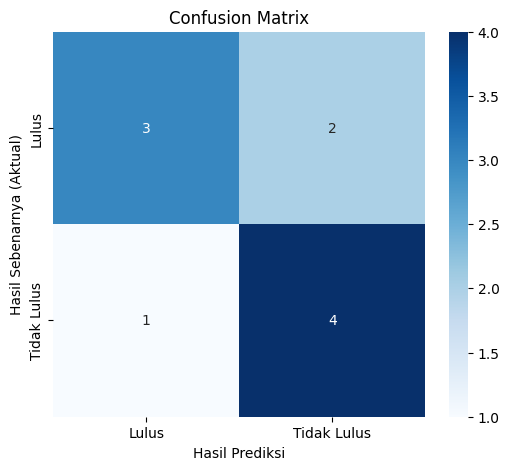

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

# ==========================================
# 1. LOAD DATA DARI EXCEL
# ==========================================
filename = 'Latihan_2.xlsx'

try:
    # Membaca file excel.
    raw_df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/praktikum_ml/praktikum10/data/Latihan_2.xlsx", header=3)


    df_columns = raw_df.iloc[0, 3:].values

    # Get the actual data, starting from the second meaningful row (index 1) and relevant columns
    df = raw_df.iloc[1:, 3:]

    # Assign the correct column names
    df.columns = df_columns

    # Reset index for the final DataFrame
    df = df.reset_index(drop=True)

    # Menampilkan 5 data teratas untuk memastikan data terbaca benar
    print("✅ Data berhasil dibaca dan diproses:")
    print(df.head())
except FileNotFoundError:
    print(f" ")
    df = None

if df is not None:
    # ==========================================
    # 2. DEFINISI VARIABEL
    # ==========================================
    # Pastikan nama kolom di bawah ini SAMA PERSIS dengan di Excel kamu
    col_actual = 'Hasil Sebenarnya'
    col_pred   = 'Hasil Prediksi'
    target_class = 'Lulus' # Kelas Positif yang kita cari

    # ==========================================
    # 3. MENGHITUNG CONFUSION MATRIX
    # ==========================================
    # Labels: Urutan [Positif, Negatif] agar posisi TP ada di kiri atas (sesuai kebiasaan)
    labels = ['Lulus', 'Tidak Lulus']

    y_true = df[col_actual]
    y_pred = df[col_pred]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # ==========================================
    # 4. MENGHITUNG METRICS
    # ==========================================
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=target_class)
    rec  = recall_score(y_true, y_pred, pos_label=target_class)

    # ==========================================
    # 5. MENAMPILKAN HASIL
    # ==========================================
    print("\n" + "="*40)
    print("      HASIL PERHITUNGAN KINERJA MODEL")
    print("="*40)
    print(f"1. Accuracy  (Akurasi) : {acc * 100:.0f}%")
    print(f"2. Precision (Presisi) : {prec * 100:.0f}%")
    print(f"3. Recall    (Sensitivitas): {rec * 100:.0f}%")
    print("="*40)

    # Menampilkan Laporan lengkap
    print("\nDetail Laporan Klasifikasi:")
    print(classification_report(y_true, y_pred, target_names=labels))

    # ==========================================
    # 6. VISUALISASI CONFUSION MATRIX
    # ==========================================
    plt.figure(figsize=(6, 5))
    # annot=True memunculkan angkanya, fmt='d' agar angka bulat (bukan desimal)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Hasil Prediksi')
    plt.ylabel('Hasil Sebenarnya (Aktual)')
    plt.title('Confusion Matrix')
    plt.show()

**Lathian 3**

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Load Data
# Menggunakan skiprows=5 karena header ada di baris ke-6 (index 5)
file_path = '/content/drive/MyDrive/Colab Notebooks/praktikum_ml/praktikum10/data/Latihan_3.xlsx'
# FIX: Use pd.read_excel for .xlsx files and specify header=5
df = pd.read_excel(file_path, header=5)

# 2. Membersihkan Data
# Menghapus kolom yang sepenuhnya kosong (biasanya muncul dari konversi Excel ke CSV)
df = df.dropna(axis=1, how='all')

# Menampilkan data awal untuk pengecekan
print("Info Data:")
print(df.info())
print("\n5 Baris Pertama:")
print(df.head())

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           10 non-null     float64
 1   Humidity              10 non-null     int64  
 2   Wind Speed            10 non-null     float64
 3   Precipitation (%)     10 non-null     float64
 4   Cloud Cover           10 non-null     object 
 5   Atmospheric Pressure  10 non-null     float64
 6   UV Index              10 non-null     int64  
 7   Season                10 non-null     object 
 8   Visibility (km)       10 non-null     float64
 9   Location              10 non-null     object 
 10  Weather Type          10 non-null     object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1012.0+ bytes
None

5 Baris Pertama:
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  pa

In [26]:
# Daftar kolom kategori yang perlu diubah jadi angka
categorical_cols = ['Cloud Cover', 'Season', 'Location', 'Weather Type']

# Kita simpan encoder agar tahu, misal: 0 = Cloudy, 1 = Rainy, dst.
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Mengisi nilai NaN dengan modus (data terbanyak) jika ada yang kosong
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("\nContoh data setelah encoding:")
print(df.head())


Contoh data setelah encoding:
   Temperature  Humidity  Wind Speed  Precipitation (%)  Cloud Cover  \
0         14.0        73         9.5               82.0            2   
1         39.0        96         8.5               71.0            2   
2         30.0        64         7.0               16.0            0   
3         38.0        83         1.5               82.0            0   
4         27.0        74        17.0               66.0            1   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2       2              3.5         1   
1               1011.43         7       0             10.0         1   
2               1018.72         5       0              5.5         2   
3               1026.25         7       0              1.0         0   
4                990.67         1       2              2.5         2   

   Weather Type  
0             1  
1             0  
2             3  
3             3  
4            

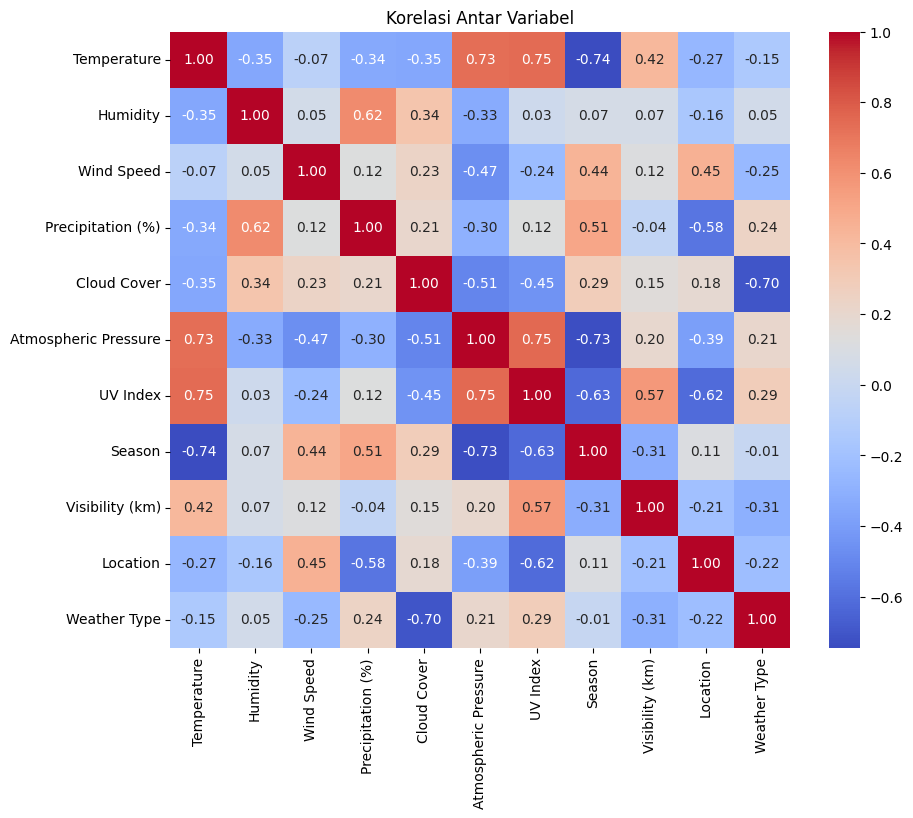

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Antar Variabel")
plt.show()

In [28]:
# Pisahkan Fitur (X) dan Target (y)
X = df.drop('Weather Type', axis=1)
y = df['Weather Type']

# Bagi data menjadi Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Latih Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)


Akurasi Model: 50.00%

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.00      0.00      0.00         1
       Rainy       0.00      0.00      0.00         0
       Snowy       1.00      1.00      1.00         1
       Sunny       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.25      0.25      0.25         2
weighted avg       0.50      0.50      0.50         2



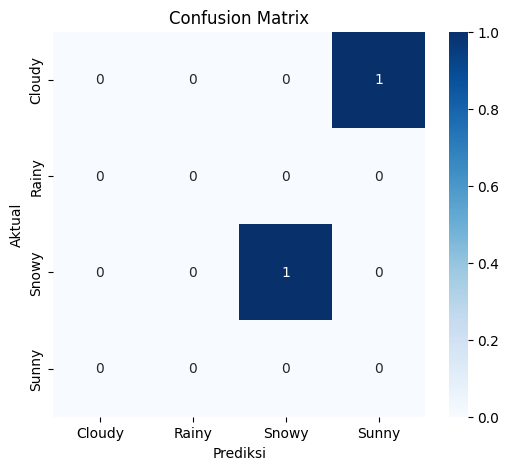

In [30]:
# Hitung Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy * 100:.2f}%")

# Laporan Klasifikasi Detail
print("\nClassification Report:")
target_names = encoders['Weather Type'].classes_
# Get all possible integer labels from 0 to max_label
all_labels = list(range(len(target_names)))
# Pass the labels explicitly to classification_report
print(classification_report(y_test, y_pred, labels=all_labels, target_names=target_names, zero_division=0))

# (Opsional) Tampilkan Confusion Matrix
plt.figure(figsize=(6,5))
# Pass the labels explicitly to confusion_matrix as well
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()